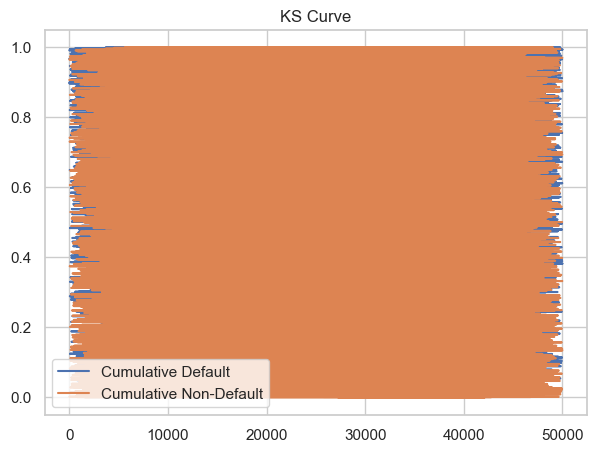

In [49]:
plt.figure(figsize=(7, 5))

plt.plot(df_ks["cum_default"], label="Cumulative Default")
plt.plot(df_ks["cum_non_default"], label="Cumulative Non-Default")

plt.title("KS Curve")

plt.legend()

plt.show()

In [48]:
df_ks["ks"] = df_ks["cum_default"] - df_ks["cum_non_default"]

ks_value = df_ks["ks"].max()

print("KS Statistic:", ks_value)

KS Statistic: 0.29355225171155497


In [47]:
df_ks["cum_default"] = df_ks["default"].cumsum() / df_ks["default"].sum()

df_ks["cum_non_default"] = ((1 - df_ks["default"]).cumsum() / (1 - df_ks["default"]).sum())

In [46]:
df_ks = df_ks.sort_values(by="prob_default", ascending=False)

In [44]:
df_ks = pd.DataFrame({
    "default": y_test,
    "prob_default": y_prob
})

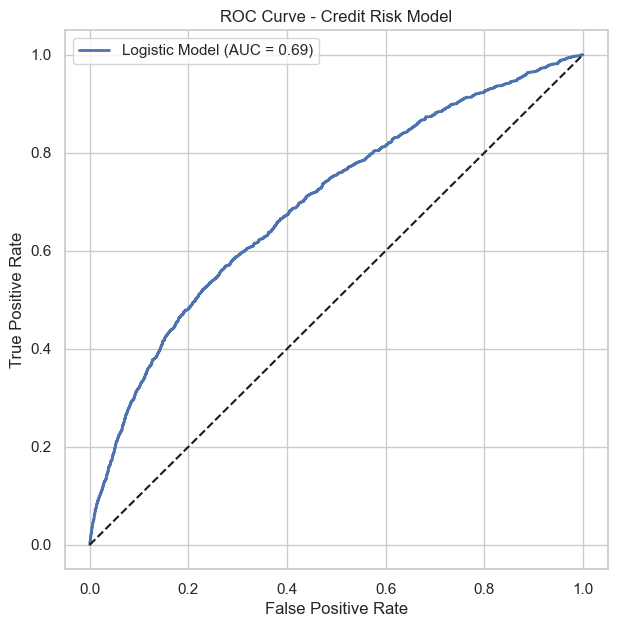

In [43]:
plt.figure(figsize=(7,7))

plt.plot(fpr, tpr, label=f"Logistic Model (AUC = {auc:.2f})", linewidth=2)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Credit Risk Model")

plt.legend()

plt.show()

In [42]:
roc_auc_score(y_test, X_test["credit_score"])

0.3110797800973321

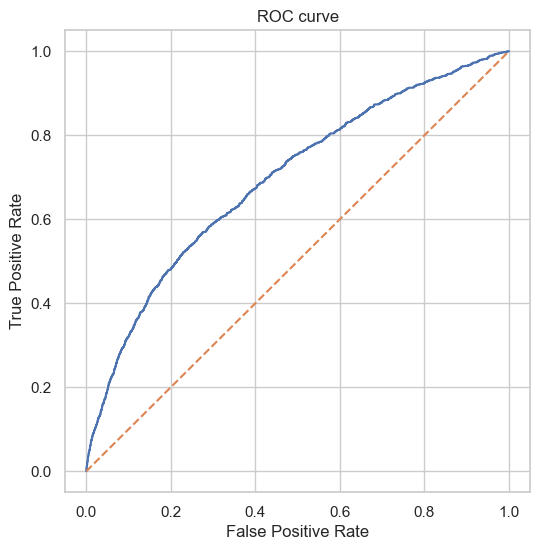

In [41]:
plt.figure(figsize=(6,6))

plt.plot(fpr,tpr, label=f"AUC = {auc:.2f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC curve")

plt.legend

plt.show()


In [39]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)

print("AUC:", auc)

AUC: 0.6947761364490294


In [38]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

In [37]:
y_prob = model.predict_proba(X_test_scaled)[:,1]

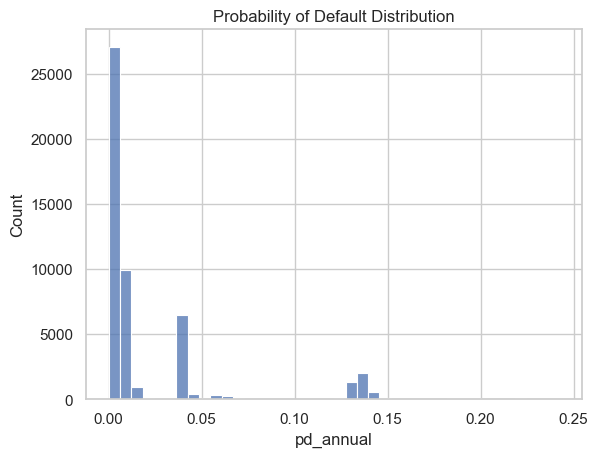

In [35]:
import seaborn as sns 

sns.histplot(df["pd_annual"], bins=40)

plt.title("Probability of Default Distribution")

plt.show()

In [33]:
df["pd_annual"].mean()

np.float64(0.02246147778)

In [32]:
importance = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_[0]
})

importance.sort_values(by="Coefficient", ascending=False)

,Variable,Coefficient
4,coupon_rate,0.205773
3,debt_to_equity,-0.006057
1,leverage,-0.010705
2,interest_coverage,-0.020403
0,credit_score,-0.615079


In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92      8594
           1       0.62      0.01      0.01      1406

    accuracy                           0.86     10000
   macro avg       0.74      0.50      0.47     10000
weighted avg       0.83      0.86      0.80     10000



In [30]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test_scaled)

confusion_matrix(y_test, y_pred)

array([[8588,    6],
       [1396,   10]])

In [29]:
model.score(X_test_scaled, y_test)

0.8598

In [27]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
X = df[["credit_score", "leverage", "interest_coverage", "debt_to_equity", "coupon_rate"]]

y =df["defaulted"]

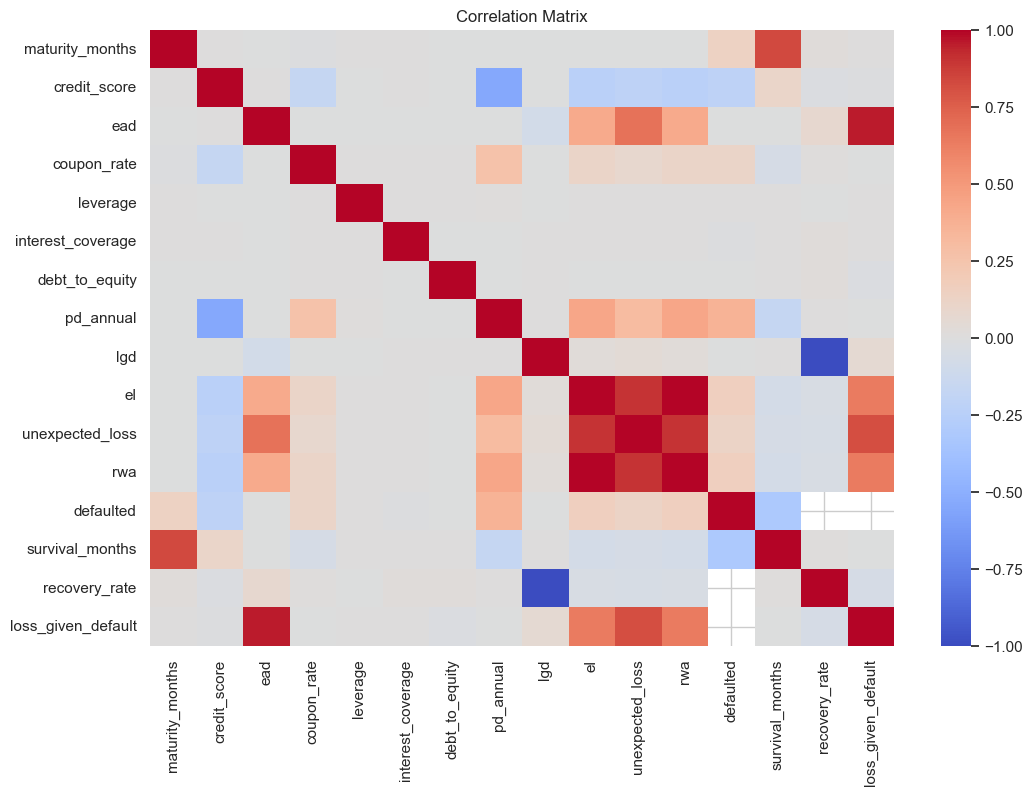

In [23]:
plt.figure(figsize=(12,8))

sns.heatmap(corr, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

In [22]:
corr = df.corr(numeric_only=True)

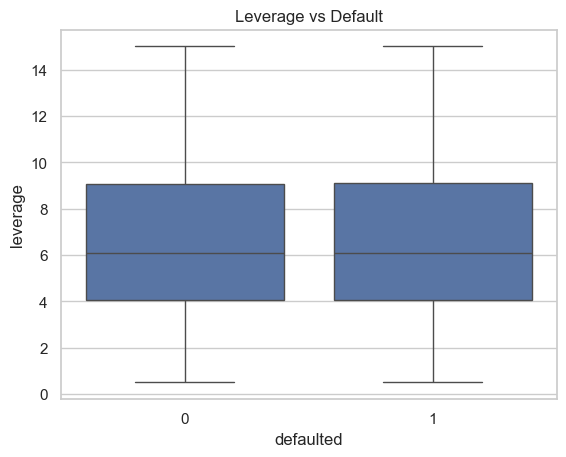

In [21]:
sns.boxplot(x="defaulted", y="leverage", data=df)

plt.title("Leverage vs Default")

plt.show()

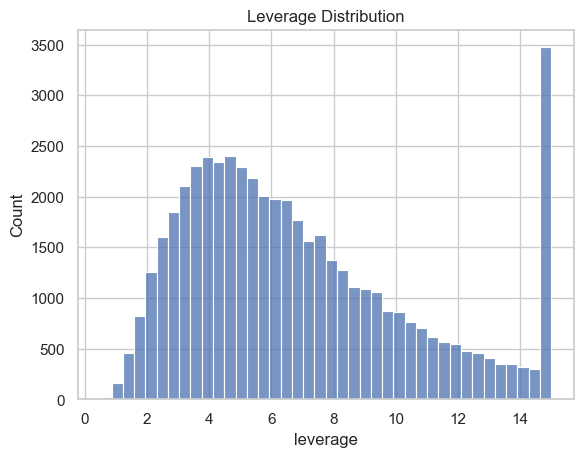

In [20]:
sns.histplot(df["leverage"], bins=40)

plt.title("Leverage Distribution")

plt.show()

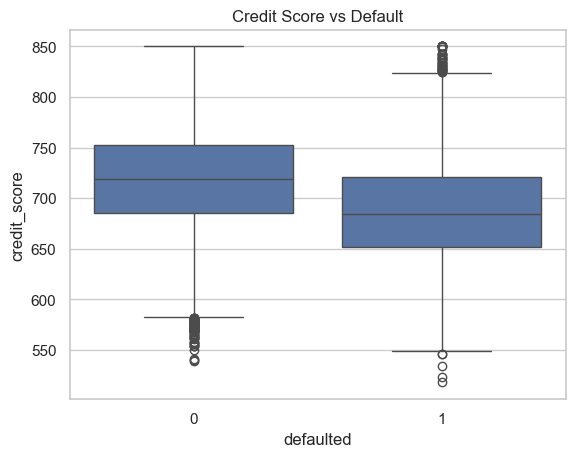

In [19]:
sns.boxplot(x="defaulted", y="credit_score", data=df)

plt.title("Credit Score vs Default")

plt.show()

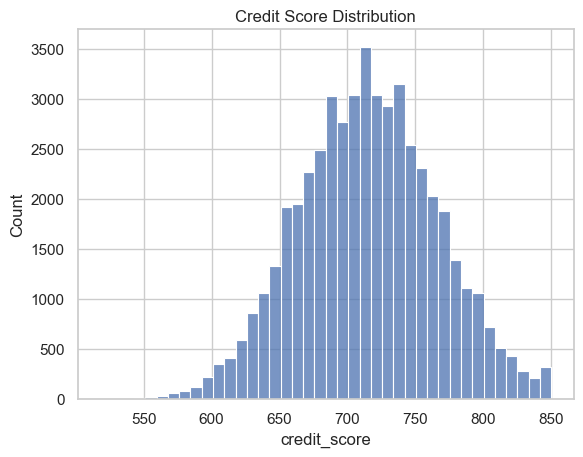

In [18]:
sns.histplot(df["credit_score"], bins=40)

plt.title("Credit Score Distribution")

plt.show()

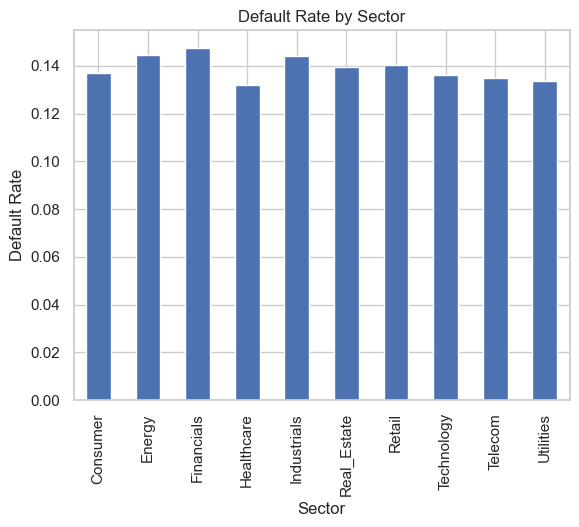

In [17]:
df.groupby("sector")["defaulted"].mean().plot(kind="bar")

plt.title("Default Rate by Sector")
plt.ylabel("Default Rate")
plt.xlabel("Sector")

plt.show()

In [16]:
df.groupby("sector")["defaulted"].mean().sort_values(ascending=False)

sector
Financials     0.147521
Energy         0.144583
Industrials    0.144054
Retail         0.140578
Real_Estate    0.139449
Consumer       0.137022
Technology     0.136318
Telecom        0.134922
Utilities      0.133495
Healthcare     0.131875
Name: defaulted, dtype: float64

In [15]:
df["defaulted"].mean()

np.float64(0.139)

In [14]:
df["defaulted"].value_counts()

defaulted
0    43050
1     6950
Name: count, dtype: int64

In [13]:
df.columns

Index(['loan_id', 'origination_date', 'maturity_date', 'maturity_months',
       'sector', 'loan_type', 'collateral', 'initial_rating', 'credit_score',
       'ead', 'coupon_rate', 'leverage', 'interest_coverage', 'debt_to_equity',
       'pd_annual', 'lgd', 'el', 'unexpected_loss', 'rwa', 'defaulted',
       'default_date', 'survival_months', 'recovery_rate',
       'loss_given_default'],
      dtype='object')

In [12]:
df.isnull().sum()

loan_id                   0
origination_date          0
maturity_date             0
maturity_months           0
sector                    0
loan_type                 0
collateral                0
initial_rating            0
credit_score              0
ead                       0
coupon_rate               0
leverage                  0
interest_coverage         0
debt_to_equity            0
pd_annual                 0
lgd                       0
el                        0
unexpected_loss           0
rwa                       0
defaulted                 0
default_date          43050
survival_months           0
recovery_rate         43050
loss_given_default    43050
dtype: int64

In [11]:
df.describe()

,maturity_months,credit_score,ead,coupon_rate,leverage,interest_coverage,debt_to_equity,pd_annual,lgd,el,unexpected_loss,rwa,defaulted,survival_months,recovery_rate,loss_given_default
count,50000.000000,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,5.000000e+04,5.000000e+04,5.000000e+04,50000.00000,50000.000000,6950.000000,6.950000e+03
mean,53.970480,714.982560,3.298605e+06,3.079087,6.913779,3.764089,2.090884,0.022461,0.546516,3.847572e+04,1.815605e+05,5.098033e+05,0.13900,49.124620,0.454562,1.713657e+06
std,26.716251,50.893411,6.661943e+06,1.103558,3.686415,2.014019,1.570126,0.040437,0.144332,1.590801e+05,4.966954e+05,2.107811e+06,0.34595,26.903824,0.145548,3.612190e+06
min,12.000000,518.000000,5.000000e+04,1.000000,0.500000,0.500000,0.100000,0.000158,0.091800,3.600000e+00,2.735300e+02,4.765000e+01,0.00000,1.000000,0.020000,1.433000e+04
25%,36.000000,679.000000,5.482685e+05,2.357000,4.060000,2.370000,1.030000,0.001229,0.442800,7.875300e+02,1.720746e+04,1.043481e+04,0.00000,36.000000,0.352900,2.915719e+05
50%,48.000000,715.000000,1.389712e+06,3.063500,6.080000,3.310000,1.650000,0.002788,0.544800,3.587830e+03,5.205993e+04,4.753875e+04,0.00000,48.000000,0.456100,7.198182e+05
75%,60.000000,750.000000,3.425439e+06,3.735000,9.070000,4.650000,2.640000,0.015868,0.646725,1.856052e+04,1.559430e+05,2.459269e+05,0.00000,60.000000,0.560275,1.750272e+06
max,120.000000,850.000000,3.611778e+08,7.531000,15.000000,20.000000,10.000000,0.242523,0.980000,6.411410e+06,2.239212e+07,8.495118e+07,1.00000,120.000000,0.857800,1.113264e+08


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   loan_id             50000 non-null  object 
 1   origination_date    50000 non-null  object 
 2   maturity_date       50000 non-null  object 
 3   maturity_months     50000 non-null  int64  
 4   sector              50000 non-null  object 
 5   loan_type           50000 non-null  object 
 6   collateral          50000 non-null  object 
 7   initial_rating      50000 non-null  object 
 8   credit_score        50000 non-null  int64  
 9   ead                 50000 non-null  float64
 10  coupon_rate         50000 non-null  float64
 11  leverage            50000 non-null  float64
 12  interest_coverage   50000 non-null  float64
 13  debt_to_equity      50000 non-null  float64
 14  pd_annual           50000 non-null  float64
 15  lgd                 50000 non-null  float64
 16  el  

In [9]:
df.shape

(50000, 24)

In [8]:
df.head()

,loan_id,origination_date,maturity_date,maturity_months,sector,loan_type,collateral,initial_rating,credit_score,ead,...,pd_annual,lgd,el,unexpected_loss,rwa,defaulted,default_date,survival_months,recovery_rate,loss_given_default
0,L000001,2017-10-01,2019-10-01,24,Technology,mortgage,secured,B,704,1035611.99,...,0.041076,0.7858,33426.80,161508.03,442905.14,0,NaN,24,NaN,NaN
1,L000002,2016-06-01,2020-06-01,48,Healthcare,term_loan,unsecured,A,702,800786.92,...,0.000887,0.7034,499.82,16771.62,6622.66,0,NaN,48,NaN,NaN
2,L000003,2023-08-01,2024-12-31,36,Real_Estate,bond,secured,BBB,699,4327864.12,...,0.002622,0.5503,6243.54,121781.72,82726.94,0,NaN,36,NaN,NaN
3,L000004,2016-04-01,2024-12-31,120,Real_Estate,term_loan,secured,B,641,3810461.19,...,0.041679,0.3541,56237.33,269661.85,745144.64,0,NaN,120,NaN,NaN
4,L000005,2015-10-01,2019-10-01,48,Energy,bond,unsecured,CCC,597,2925538.53,...,0.136071,0.6576,261778.69,659614.05,3468567.58,0,NaN,48,NaN,NaN


In [7]:
df = pd.read_csv("loan_portfolio.csv")

In [6]:
os.listdir()

['credit_ratings.csv',
 'credit_risk_analysis.ipynb',
 'loan_portfolio.csv',
 'macro_stress_scenarios.csv',
 'portfolio_metrics.csv',
 'vintage_analysis.csv']

In [5]:
import os 
os.getcwd()

'c:\\Users\\DELL\\Documents\\credit_risk_analysis\\Notebook'

In [4]:

sns.set(style="whitegrid")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns